# Parcial LDD - Resuelto

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
from gapminder import gapminder
from sklearn.datasets import make_blobs

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
mpg = sns.load_dataset("mpg")

## Turno Tarde

#### ¿Cuál(es) de los siguientes algoritmos pertenece(n) a la categoría de Aprendizaje Supervisado?

Seleccione una:
- ✅ KNN 
- K-means
- DBSCAN
- KNN y DBSCAN
- K-means y KNN
- DBSCAN y K-means
- Ninguna de las anteriores
- Todos son correctas

<a id="day_avg"> </a>
#### Ingresar un código para agregarle al dataset tips una columna llamada day_avg con el promedio de las cuentas (columna total_bill) del día (columna day).

 Por ejemplo, si el promedio del día Sat es 14.02, cada entrada que corresponda al día Sat debe tener el valor 14.02 en la columna day_avg

Utilizar el siguiente código para cargar los datos.

```python
import seaborn as sns


tips = sns.load_dataset("tips")
```

`DataFrameGroupBy` (la clase de retorno de `pd.DataFrame.groupby(...)`) tiene un método [`transform`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.transform.html) _que respeta la forma (`shape`) original de los grupos_, además del más conocido `aggregate` (que reduce las filas del DataFrame a las combinaciones únicas de las columnas agrupadoras):

In [2]:
tips["day_avg"] = tips.groupby("day").total_bill.transform("mean")

/var/folders/4h/7ndr70pd3j178zcftn42zhsw0000gn/T/ipykernel_19532/2277528171.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips["day_avg"] = tips.groupby("day").total_bill.transform("mean")


O sin `transform`,

In [3]:
daily_avgs = tips.groupby("day").total_bill.mean()  # Esto resulta en una serie
# Tomo solo `values` porque el índice sigu siendo el de `daily_avgs`
tips["day_avg"] = daily_avgs.loc[tips.day].values
tips["day_avg"] = daily_avgs.reindex(tips.day).values
# O con una comprensión de listas básica
tips["day_avg"] = [daily_avgs[day] for day in tips.day]

/var/folders/4h/7ndr70pd3j178zcftn42zhsw0000gn/T/ipykernel_19532/3322752386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_avgs = tips.groupby("day").total_bill.mean()  # Esto resulta en una serie


#### El siguiente código genera tres nubes alargadas de puntos.

Dar un código para realizar las siguientes tareas:

- Agrupar los datos en 3 clusters utilizando DBSCAN especificando parámetros `eps` y `min_samples` apropiados, dejando un máximo de 20 outliers.

- Repetir el gráfico, coloreando los clusters según la etiqueta obtenida por `DBSCAN`.

- Contar la cantidad de outliers.

No olvide especificar el código necesario para importar cualquier librería adicional a las importadas aquí debajo.

Importante: realizar el agrupamiento usando los datos `X_aniso` (no los datos originales `X`).

```python
import seaborn.objects as so
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=500, random_state=170)
transformation = [[6., -6.], [-4., 8.]]
X_aniso = np.dot(X, transformation)

so.Plot(x = X_aniso[:,0], y = X_aniso[:,1]).add(so.Dot())

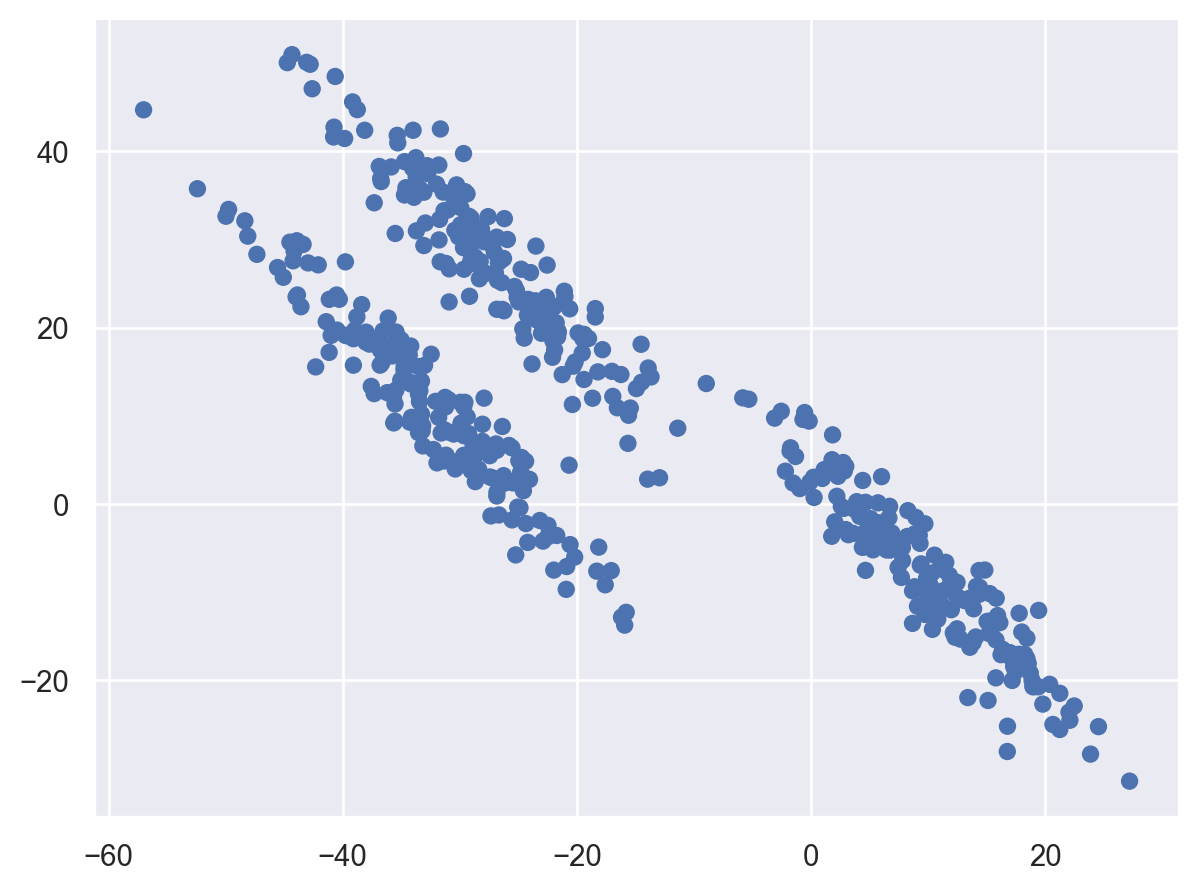

In [4]:
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=500, random_state=170)
transformation = [[6.0, -6.0], [-4.0, 8.0]]
X_aniso = np.dot(X, transformation)

so.Plot(x=X_aniso[:, 0], y=X_aniso[:, 1]).add(so.Dot())

In [5]:
from sklearn.cluster import DBSCAN

clusters = DBSCAN(eps=5, min_samples=5).fit_predict(X_aniso)

pd.Series(clusters).value_counts()

 1    167
 0    166
 2    166
-1      1
Name: count, dtype: int64

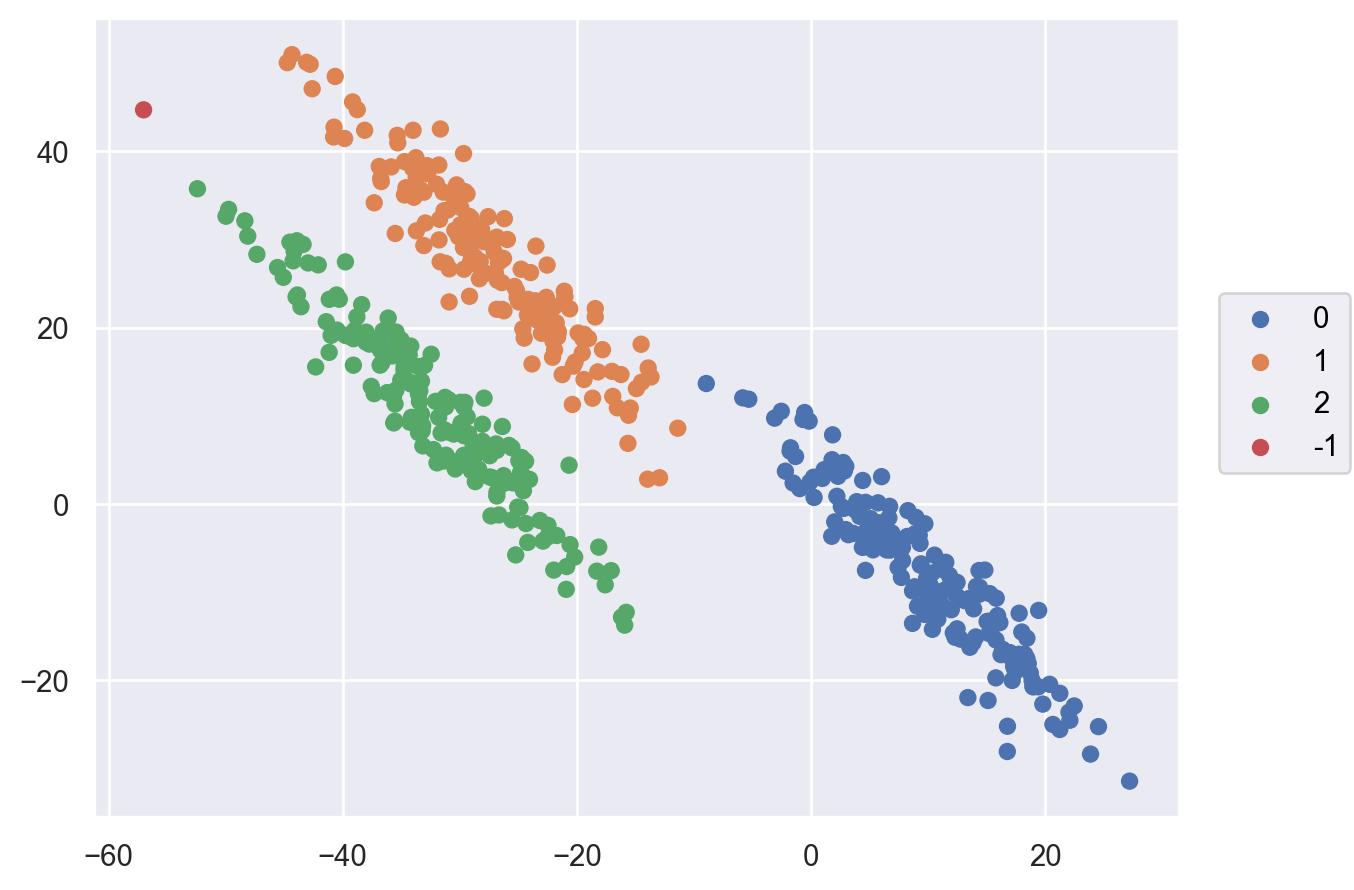

In [6]:
so.Plot(x=X_aniso[:, 0], y=X_aniso[:, 1]).add(so.Dot(), color=clusters.astype(str))

#### Leave-one-out es un caso específico de K-Fold Cross-validation

- ✅ Verdadero
- Falso

En particular, cuando `k == n_samples`, K-Fold se convierte en LOO.

#### ¿Cuáles de los siguientes modelos NO son modelos de Regresión Lineal?

A.	 $Y = \beta_0 + \beta_1 X^2$

B.	 $Y = \beta_0 + \beta_1 X + \beta_2sen(Z)$

C.	 $Y = \beta_0 + \beta_1sen(\beta_2X)$

D.	 $Y = \beta_0 + \beta_1(X^2 / Z)$

E.	 $Y = \beta_0 + \beta_1e^{\beta_2X}$

Seleccione una:
Todos son modelos de Regresión Lineal
Ninguno es un modelo de Regresión Lineal
- B), C) y E)
- E)
- ✅ C) y E)
- B) y C)
- D) y E)

Todos los demás son lineales en los coeficientes $\beta_i$.

#### A partir del DataSet penguins, dar un código de una sola línea para eliminar las filas con datos faltantes, resetear los índices (y "dropear" el original) y agregar "pinguinos_" al principio del nombre de todas las columnas.

Cargar el dataset con el siguiente codigo.

```python
import seaborn as sns


penguins = sns.load_dataset('penguins')

In [7]:
penguins = sns.load_dataset("penguins")
penguins = penguins.dropna().reset_index(drop=True).add_prefix("pinguinos_")

#### Un DataFrame `data` contiene algunas columnas que comienzan con las letras "IMPO" y otras columnas que comienzan con "EXPO".
En un código de una sola línea, crear un nuevo DataFrame `data_impo` que contenga solo las columnas de data que comiencen con "IMPO".

In [8]:
data = pd.DataFrame(
    np.random.uniform(size=(5, 4)), columns=["IMPO_A", "IMPORT", "EXPO_A", "EXPORT"]
)
data

,IMPO_A,IMPORT,EXPO_A,EXPORT
0,0.277997,0.077924,0.108676,0.346741
1,0.350070,0.573058,0.061861,0.033361
2,0.581035,0.526012,0.604875,0.395980
3,0.056822,0.956732,0.479934,0.757510
4,0.153678,0.958755,0.655729,0.369413


[`pd.DataFrame.filter`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.filter.html#pandas.DataFrame.filter) es la manera más "pandesca", pero también lo sabemos hacer con list-comps:

In [9]:
data_impo = data.filter(like="IMPO")
data_impo = data[[col for col in data.columns if col.startswith("IMPO")]]

#### Una cierta matriz de covarianza tiene los siguientes autovalores:

$ \lambda_1 = 3 \;\; \lambda_2= 7 \;\; \lambda_3=12 \;\; \lambda_4 =4 \;\; \lambda_5=8 $

¿Cual es la menor cantidad de componentes principales necesaria para explicar el 90% de la varianza de los datos?

In [10]:
avals = np.array([3, 7, 12, 4, 8])
avals.sort()
min_var = 0.9
# [::-1] reordena una lista del primero al último elemento
var_explicada = avals[::-1].cumsum() / avals.sum()
np.argmax(var_explicada > min_var) + 1

4

#### Ingresar un código para generar el siguiente gráfico a partir de datos del dataset tips

En el eje y se encuentra el total de propinas recibidas, en el eje x los días, y con distintos colores, barras correspondiente a "Lunch" y "Dinner".

```python
import seaborn as sns
import seaborn.objects as so

tips = sns.load_dataset('tips')

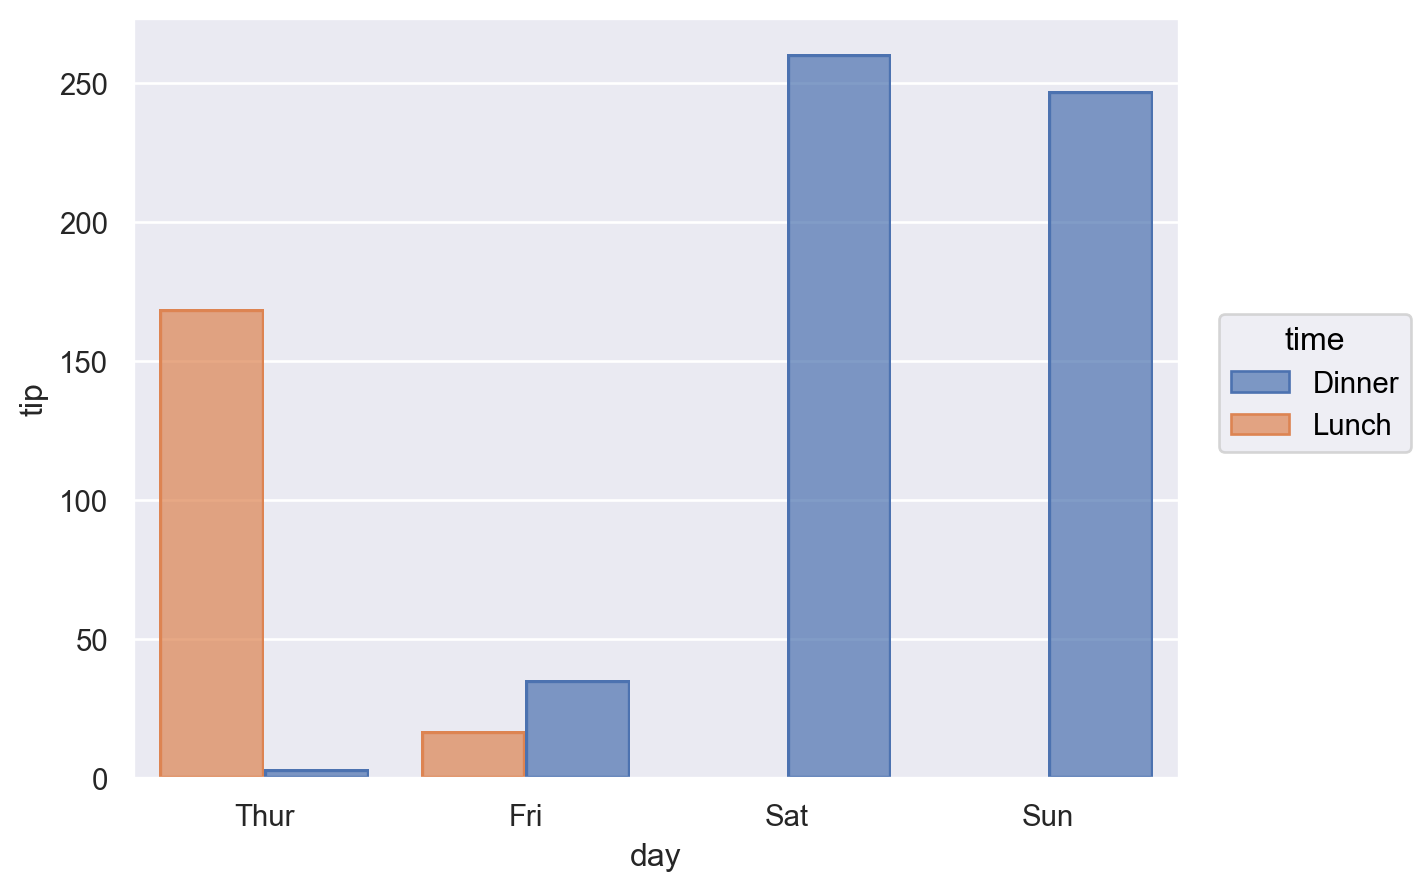

In [11]:
import seaborn as sns
import pandas as pd


tips = sns.load_dataset("tips")
so.Plot(data=tips, x="day", y="tip", color="time").add(
    so.Bar(), so.Agg("sum"), so.Dodge()
)

#### Para un DataFrame data de 5 variables y 100 observaciones, dar un código para escalar linealmente cada columna al intervalo [0, 5].

Es decir, el mínimo de cada columna debe ir al 0 y el máximo de cada columna debe ir al 5.

Lo resolvemos un poco más generalmente, para reescalar una columna entre dos valores arbitrarios, `low` y `high`

In [12]:
# Generamos un dataframe de testeo
n, p = 100, 5
data = pd.DataFrame({"var%i" % i: np.random.uniform(-i, i, n) for i in range(1, p + 1)})

In [13]:
def escalar(s, low=0, high=1):
    minimo, maximo = s.min(), s.max()
    return low + (s - minimo) / (maximo - minimo) * (high - low)


data = data.apply(escalar, high=5)

In [14]:
data.aggregate(["min", "max"])

,var1,var2,var3,var4,var5
min,0.0,0.0,0.0,0.0,0.0
max,5.0,5.0,5.0,5.0,5.0


#### Para el siguiente conjunto de 8 datos, se realiza un gráfico de dispersión de la matriz de datos centrados $X^\star = X - \bar X$.

```python
import numpy as np
import seaborn.objects as so


X = np.array([[1, 2], [2, -1], [3, -2], [4, 0], [2.5, 1], [3.7, 0.5], [1,0], [0,1]])
X_star = X - X.mean(axis = 0)
(
 so.Plot()
 .add(so.Dot(), x = X_star[:,0], y = X_star[:,1])
)
```
¿Cuál es la primera dirección principal $u_1$ y cuál es la proyección de los datos sobre esta dirección $z_1$?

Seleccione una
- $u_1 = (0.80, -0.59)$ y $z_1 = (-2.0, 0.59, -1.28, -1.60, -0.2, 1.06, -0.81, -2.21)$
- ✅ $u_1 = (0.80, -0.59)$ y $z_1 = (-2.0, 0.59, 1.98, 1.60, -0.2, 1.06, -0.81, -2.21)$
- $u_1 = (0.80, 0.59)$ y $z_1 = (-2.0, 0.59, -1.28, -1.60, -0.2, 1.06, -0.81, -2.21)$
- $u_1 = (0.80, 0.59)$ y $z_1 = (-2.0, 0.59, 1.98, 1.60, -0.2, 1.06, -0.81, -2.21)$

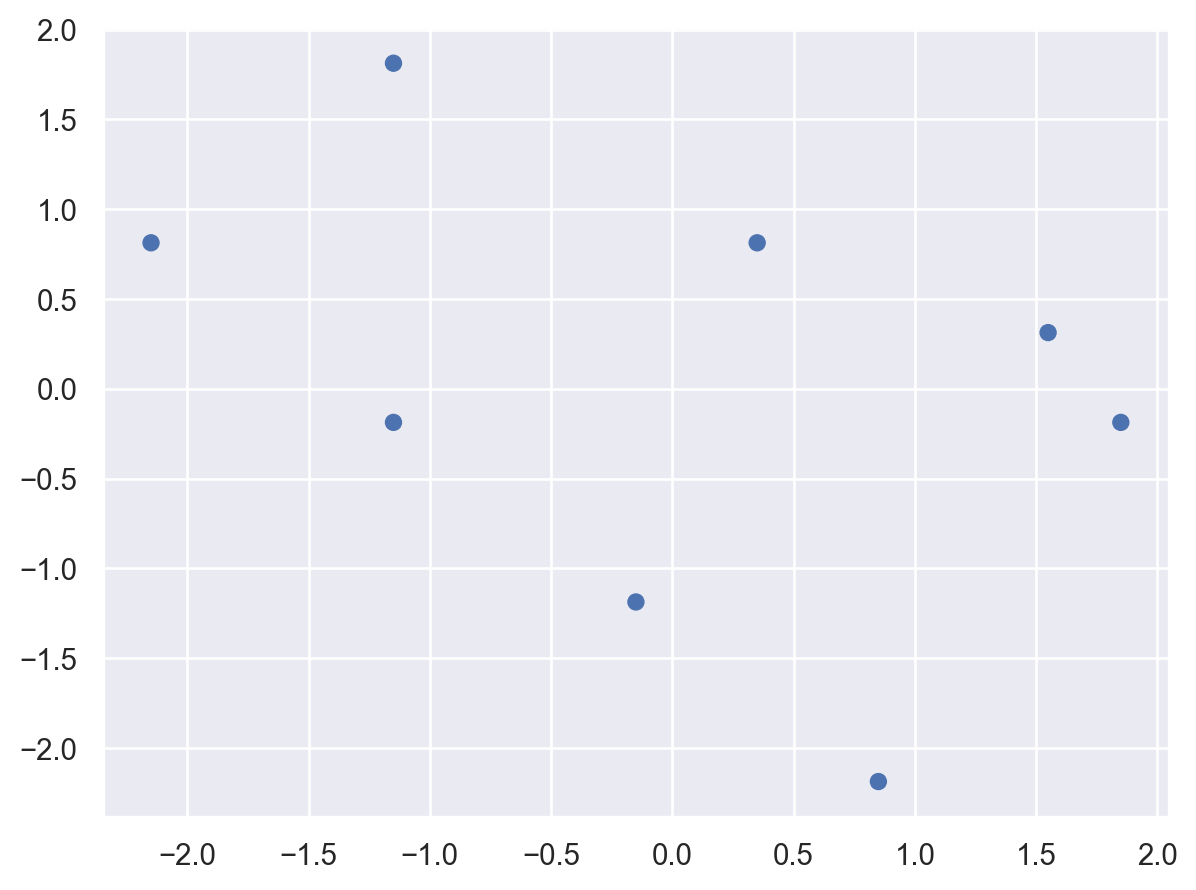

In [15]:
import numpy as np
import seaborn.objects as so


X = np.array([[1, 2], [2, -1], [3, -2], [4, 0], [2.5, 1], [3.7, 0.5], [1, 0], [0, 1]])
X_star = X - X.mean(axis=0)
(so.Plot().add(so.Dot(), x=X_star[:, 0], y=X_star[:, 1]))

Acá tomamos una sola componente principal. También pueden pedirlas todas (`PCA()` sin argumentos) y luego tomar sólo la primera (`pca.components_[0]`).

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1).fit(X_star)
pca.components_[0].round(2)  # Primer dirección principal u_1

array([ 0.8 , -0.59])

Las proyecciones se pueden calcular a mano, o con `PCA.transform`:

In [17]:
assert np.allclose(X_star @ pca.components_.T, pca.transform(X_star))
pca.transform(X_star).round(2).T

array([[-2.  ,  0.59,  1.98,  1.6 , -0.2 ,  1.06, -0.81, -2.21]])

#### A partir de los datos de Gapminder se quiere calcular la mediana de los valores de PBI ("GDP") (el producto del PBI per cápita, gdpPerCap y su población, pop) en el año 1997.

¿Cuál es el código para hacerlo y cuál es el valor de la mediana?

Utilizar este código para cargar los datos:

```python
from gapminder import gapminder
 

##### 🚨 OJO 🚨: Columnas con nombres idénticos a métodos de `pd.DataFrame`
Toda columna de un DataFrame es a su vez un atributo del mismo. Por eso, `gapminder["gdp"]` y `gapminder.gdp` devuelven la misma serie. Ahora bien, cuando una columna tiene el mismo nombre que un método del DataFrame, toma precedencia el método.

Luego, `gapminder.pop` es el método [`pop`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pop.html) cpte. a la instancia `gapminder` de la clase `DataFrame`, y la columna sólo es accesible vía las claves, `gapminder["pop"]`

In [18]:
try:
    gapminder["gdp"] = gapminder.gdpPercap * gapminder.pop
except TypeError as err:
    print(err)

unsupported operand type(s) for *: 'float' and 'method'


In [19]:
gapminder["gdp"] = gapminder.gdpPercap * gapminder["pop"]
gapminder[gapminder.year == 1997].gdp.median()

37473838314.64542

#### En un modelo de regresión lineal, al minimizar el Error Cuadrático Medio con el método matricial, se obtiene el mínimo global.

Recordar: el método matricial consiste en calcular los parámetros \beta resolviendo el sistema lineal $ A^T A \beta = A^T y$

 - ✅ Verdadero
 - Falso

 La función de pérdida cpte. al ECM es convexa en los $\beta_i$, así que salvo que el problema esté mal condicionado, o haya más predictores $p$ que observaciones $n$, hay un único mínimo, que es el global.

#### Al entrenar una red neuronal para decidir si una persona tiene cierta enfermedad (SI o NO) a partir de distintas características, como función de pérdida deberíamos usar:

Seleccione una:
- Error cuadrático medio
- ✅ Binary Cross-Entropy
- La función sigmoidea
- Ninguna es apropiada

ECM es apropiada en regresión, y la función sigmoidea es una función de activación más que de pérdida.

#### Se quiere realizar un modelo de regresión Ridge. Para seleccionar un valor de alfa apropiado, se experimenta con distintos valores de alfa. 

**(FIGURA EN AMBOS TURNOS)**

Si se selecciona el valor $\alpha = 1$, ¿cuál es el gráfico que corresponde al experimento descripto? Tener en cuenta cómo se selecciona el valor de alfa óptimo y cómo varía el ECM en los conjuntos de entrenamiento y validación al variar el parámetro alfa.

![correcta](img/train-val.png)

En Ridge, el modelo menos regularizado corresponde a $\alpha = 0$, y se vuelve más "rígido" a medida que crece, así que el mínimo ECM de entrenamiento debe estar en el 0. Además, si elegimos $\alpha=1$, es porque el _mínimo_ ECM corresponde a dicho valor, no el _máximo_.

#### Para realizar un modelo de regresión se quiere escalar las variables explicativas. Si además se quiere separar los datos en conjuntos de entrenamiento y testeo, ¿cuál es la forma correcta de aplicar el escalamiento MinMax?

**(FIGURA EN AMBOS TURNOS)**

La respuesta correcta es :
```python
X_train, X_test = train_test_split(X, test_size = 0.2)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

Las llamadas a `scaler.fit(...)` devuelven el objeto `MinMaxScaler` ajustado, no la data transformada, para eso hay que llamar a `scaler.transform`. Además, si llamamos a `fit_transform` sobre los datos de testeo, vamos a reajustar el transformador y "pisar" lo aprendido en entrenamiento, que es la única info disponible a la hora de entrenar un estimador a posteriori.

#### Se quiere estimar el nivel de colesterol en sangre por regresión lineal utilizando los siguientes datos de los pacientes: índice de masa corporal, minutos de ejercicio físico diario, cantidad de grasas ingeridas por día.

Si se agrega una nueva variable "último dígito del DNI del paciente", y se compara con el modelo anterior mediante un esquema de entrenamiento y testeo, como espera que se modifique el error cuadrático medio (ECM):

Seleccione una:
- Aumenta el ECM tanto en entrenamiento como en testeo.
- Disminuye o se mantiene igual el ECM en entrenamiento y testeo.
- ✅ Disminuye o se mantiene igual el ECM en entrenamiento y aumenta en testeo.
- Aumenta el ECM en entrenamiento y disminuye o se mantiene igual en testeo.

Agregar una variable "no informativa" como el "último dígito del DNI del paciente", puede causar un sobreajuste durante el entrenamiento que disminuya el ECM allí, pero no generalizará bien a datos no vistos y puede perjudicar el ECM de testeo.

#### Al terminar el entrenamiento de una Red Neuronal, se observa el siguiente gráfico que describe la evolución de la función de pérdida a lo largo de todas las eṕocas.

¿Qué se puede concluir?

![entrenamiento-nn-tt](img/entrenamiento-nn-tt.png)

Seleccione una:
- Se observa overfitting, hay que disminuir la cantidad de épocas para entrenamiento
- La cantidad de épocas para el entrenamiento es satisfactoria
- ✅ Se debe aumentar la cantidad de épocas para el entrenamiento, la red todavía puede mejorar su desempeño.
- No se puede concluir nada.

Como la pendiente de la pérdida en el conjunto de entrenamiento todavía es negativa hacia la última época (el el borde derecho del gráfico), y la función es "continua y suave", esperaríamos que la pérdida siga disminuyendo un tiempo más de seguir entrenando la red. 

A partir de datos sobre planetas en galaxias lejanas, se realiza un gráfico de dispersión utilizando la masa (mass) como variable X y la distancia a nuestra galaxia (distance) como variable Y.

![](img/scatter.png)

Si realizamos un gráfico box plot de la variable mass, ¿cuál de los 4 gráficos es correcto?

Seleccione una:

![](img/boxplot.png)

Las demás opciones tienen todas algo extraño: una tiene el mínimo valor en 5, otra tiene el máximo valor en 14, y la tercera no tiene valores entre 5 y 10, por fuera de los bigotes, cuando el scatter claramente muestra puntos en esa región.

#### En el dataset tips de propinas, la variable size indica cuántos clientes había en la mesa y la variable total_bill indica cuánto gastaron en total en la mesa.

Agregar al dataset una columna client_bill que muestre lo que gastó cada cliente (considerando que se reparten el valor de la comida equitativamente) y otra columna lt_10 que indique si lo que gastó cada cliente fue menor que $10 (1 en caso afirmativo, 0 en caso negativo).

Utilizar este código para cargar los datos:

```python
import seaborn as sns


tips = sns.load_dataset('tips')

Aquí corre la misma advertencia que con respecto a `gapminder["pop"]`, pues [`size`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.size.html) es un atributo de `pd.DataFrame`

In [20]:
tips["client_bill"] = tips.total_bill / tips["size"]
tips["lt_10"] = (tips.client_bill < 10).astype(int)

#### ¿En cuál(es) de estos conjuntos de datos DBSCAN (con parámetros convenientes) daría los resultados que uno espera?

![](img/dbscan.png)

Seleccione una:
- A)
- B)
- ✅ Ambos
- Ninguno

A priori, los clusters están bien separados en ambos ejemplos, no hay demasiado ruido, y no se solapan, DBSCAN deberían andar de pelos en ambos.

#### Se tiene la siguiente fórmula de Wilkinson:

$$Y \sim (X * W) + W : Z -  1$$

donde Y, X, W son variables numéricas y Z es categórica. La fórmula...

Seleccione una:
- Tiene intercept
- Contempla la suma de Z con W
- ✅ Contempla la interacción de W con las demás variables explicativas
- Ninguna es correcta
- Todas son correctas

La expansión de la fórmula queda $Y \sim X + X:W + W + W : Z -  1$. El $-1$ en la fórmula explícitamente elimina el intercept. Aunque $W$ sí aparece solo, $Z$ sólo está interactuado con $W$, así que ni (a) hay una columna literal $I(Z + W)$, ni (b) hay columnas independientes $Z, W$ tales que uno podría reescribir el modelo como $I(Z + W), W$ para "contemplar la suma de Z con W".

Los términos que sí figuran, son $W:Z, W:X$, que cubren las interacciones "con las demás variables explicativas".

#### El siguiente gráfico permite comparar directamente la mediana de propinas que dejan los clientes por día:

![](img/boxplots.png)

Seleccione una:
- ✅ Verdadero
- Falso

La línea central de la "caja" en un boxplot es su mediana, así que una inspección ocular basta para compararlas.

#### Se tienen 5 datos de 2 categorías: rojo y azul. Se desea utilizar el algoritmo de KNN para clasificar a un nuevo dato, indicado en el gráfico con la estrella.

Decidir si el siguiente enunciado es verdadero o falso:

_Con K=3 se clasifica al nuevo dato como azul._

![](img/knn.png)

Seleccione una:
- ✅ Verdadero
- Falso

Los $K=3$ puntos más cercanos a la estrella son los 3 más a la derecha del gráfico, 2 de ellos son azules y $2/3 > 1/2$, así que "gana azul".

#### ¿Cuál(es) de los siguientes algoritmos pertenece(n) a la categoría de Aprendizaje Supervisado?

Seleccione una:
- ✅ KNN
- K-means
- DBSCAN
- KNN y DBSCAN
- K-means y KNN
- DBSCAN y K-means
- Ninguna de las anteriores
- Todos son correctas

K-means y DBSCAN son algoritmos de _clustering_, es decir, aprendizaje _no_ supervisado.

## Turno Noche
Aquí, sólo las referencias a las preguntas que son sustancialmente distintas a las del Turno Tarde. 

#### La implementación computacional del algoritmo de Descenso por Gradiente siempre converge al óptimo global

Seleccione una:
- Verdadero
- ✅ Falso

Si la función tiene un único mínimo global, y la secuencia de tasas de aprendizaje tiende a cero, y la función a optimizar es suficientemente suave, et cetera, sí converge al óptimo global. Pero desde ya que no siempre se cumplen estos prerrequisitos.

#### Para cierto conjunto X de datos cuya media de cada columna viene dada por el vector

$\mu = (0.5, 0.2, 0.6, 0.8) $
las primeras direcciones principales son

$u_1 = (0.45, 0, 0, 0.89)$
$u_2 = (0, 1, 0, 0)$
 

El primer dato de X es:

$x_0 = (0.4, 0, 0.9, 1.4)$
¿Cuál es la proyección del primer dato sobre las dos direcciones principales?

Seleccione una:
- $(1.426, 0)$
- ✅ $(0.489, -0.2)$
- $(1.4, 0.9)$
- $(0.4, 0)$

Es cuestión de realizar la cuenta adecuada: $z_0 = (x_0 - \mu) \times U$, donde $U$ es la matriz de $4 \times 2$ que tiene por columnas a los vectores $u_1, u_2$.


#### Ingresar un código para agregarle al dataset `tips` una columna `tip_ratio` que muestre la proporcion de la propina (`tip`) respecto de lo que costó la comida (`total_bill`) y otra columna `large_ratio` que indique si la propina fue mayor que el $10\%$ del valor de la comida (1 en caso afirmativo, 0 en caso negativo)

 

```python
import seaborn as sns

tips = sns.load_dataset('tips')
```

In [21]:
tips["day_std"] = tips.groupby("day").total_bill.transform("std")

/var/folders/4h/7ndr70pd3j178zcftn42zhsw0000gn/T/ipykernel_19532/3845722714.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips["day_std"] = tips.groupby("day").total_bill.transform("std")


Para más alternativas sin `transform`, [cónfer](https://es.wikipedia.org/wiki/Confer) la pregunta [equivalente](#day_avg) del Turno Tarde, con `day_avg`.

In [22]:
tips["tip_ratio"] = tips.tip / tips.total_bill
tips["large_ratio"] = (tips.tip_ratio > 0.1).astype(int)

#### Ingresar un código para agregarle al dataset tips una columna llamada day_std con el desvio estandar de las propinas (tip) del día (day).

Por ejemplo, si el desvio estandar del día Sat es 1.02, cada entrada que corresponda al día Sat debe tener el valor 1.02 en la columna day_std

```python
import seaborn as sns


tips = sns.load_dataset('tips')

#### A partir de los datos de Gapminder se quiere calcular el desvío estándar de los valores de todos los países de gdpPercap / lifeExp en el año 2002.

¿Cuál es el código para hacerlo y cuál es el valor del desvío estándar?

```python
from gapminder import gapminder

Hay mil formas de hacerlo, aquí una que tal vez no conocían con [`eval`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.eval.html)

In [23]:
gapminder[gapminder.year == 2002].eval("gdpPercap / lifeExp").median()

78.09145422145872

#### Al terminar el entrenamiento de una Red Neuronal, se observa el siguiente gráfico que describe la evolución de la función de pérdida a lo largo de todas las eṕocas.

¿Qué se puede concluir?

![entrenamiento-nn-tn](img/entrenamiento-nn-tn.png)

Seleccione una:
- ✅ Se observa overfitting, hay que disminuir la cantidad de épocas para entrenamiento
- La cantidad de épocas para el entrenamiento es satisfactoria
- Se debe aumentar la cantidad de épocas para el entrenamiento, la red todavía puede mejorar su desempeño.
- No se puede concluir nada.

Hacia la derecha del gráfico, vemos que en las últimas épocas el error de validación sube, mientras que el de entrenamiento baja, clara señal de overfitting.

#### A partir del DataFrame tips, dar un código de una sola línea para eliminar las filas con datos faltantes, eliminar la columna smoker y renombrar las columnas total_bill y tip a valor y propina, respectivamente.

```python
import seaborn as sns


tips = sns.load_dataset('tips')

Por cuestiones de formateo y para comodidad del lector, como el "one-liner" ocupa más de 90 caracteres lo verán partido en varias líneas, pero sigue siendo una encadenación.

In [24]:
tips = (
    tips.dropna()
    .drop(columns="smoker")
    .rename(columns={"total_bill": "valor", "tip": "propina"})
)

#### A partir de los datos de modelos de autos disponibles en el DataFrame `mpg` de `seaborn`, dar un código para graficar utilizando Seaborn Objects un histograma de la cantidad de modelos por región de origen (variable `origin`) que tienen mas de 80 caballos de fuerza (variable `horsepower`) y exactamente 4 cilindros (variable `cylinders`).

Utilizar este código para cargar los datos:

```python
import seaborn as sns
import seaborn.objects as so


mpg = sns.load_dataset("mpg")

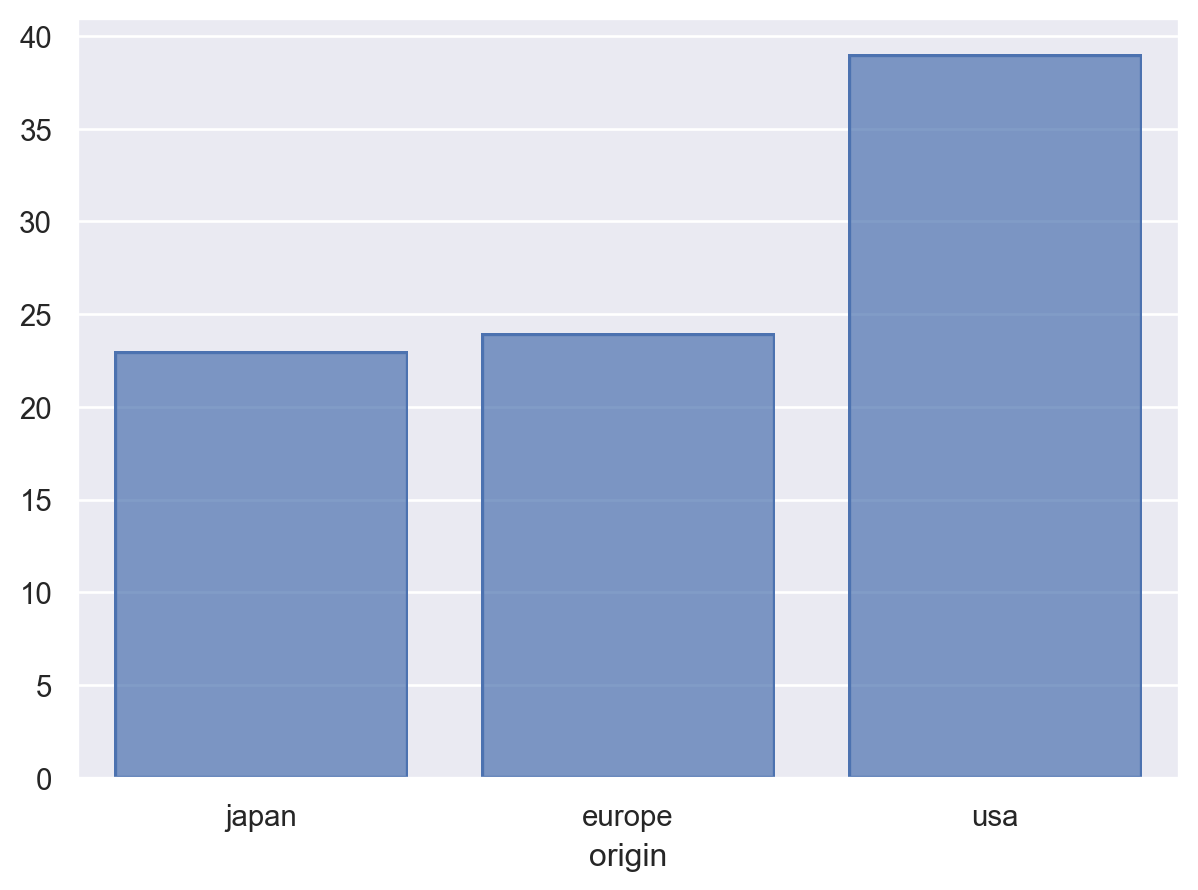

In [25]:
(
    so.Plot(mpg[(mpg.horsepower > 80) & (mpg.cylinders == 4)], x="origin").add(
        so.Bar(), so.Hist()
    )
)

#### ¿Cuál(es) de los siguientes algoritmos pertenece(n) a la categoría de Aprendizaje no Supervisado?

Seleccione una:
- KNN
- Regresión logística
- Regresión Lineal
- KNN y Regresión Lineal
- KNN y Regresión logística
- Regresión Logística y Regresión Lineal
- Todas son correctas
- ✅ Ninguna es correcta

KNN (para clasificación y regresión), Regresión Logística (para clasificación) y Regresión Lineal (para regresión) son todos algoritmos de aprendizaje _supervisados_.

#### El siguiente código genera tres nubes de puntos.

Dar un código para realizar las siguientes tareas:

- Sin escalar los datos, agruparlos utilizando K-Means con el valor de K apropiado.
- Repetir el gráfico, coloreando los clusters según la etiqueta obtenida por K-Means y graficando la posición de los centroides en color negro.
- Calcular a qué cluster correspondería el punto $(-4, -2)$ (si lo requiere, para calcular norma entre vectores se puede usar la función `np.linalg.norm`)

 
```python
from sklearn.datasets import make_blobs
import numpy as np


X, y = make_blobs(n_samples=500, random_state=170)
so.Plot(x = X[:,0], y = X[:,1]).add(so.Dot())

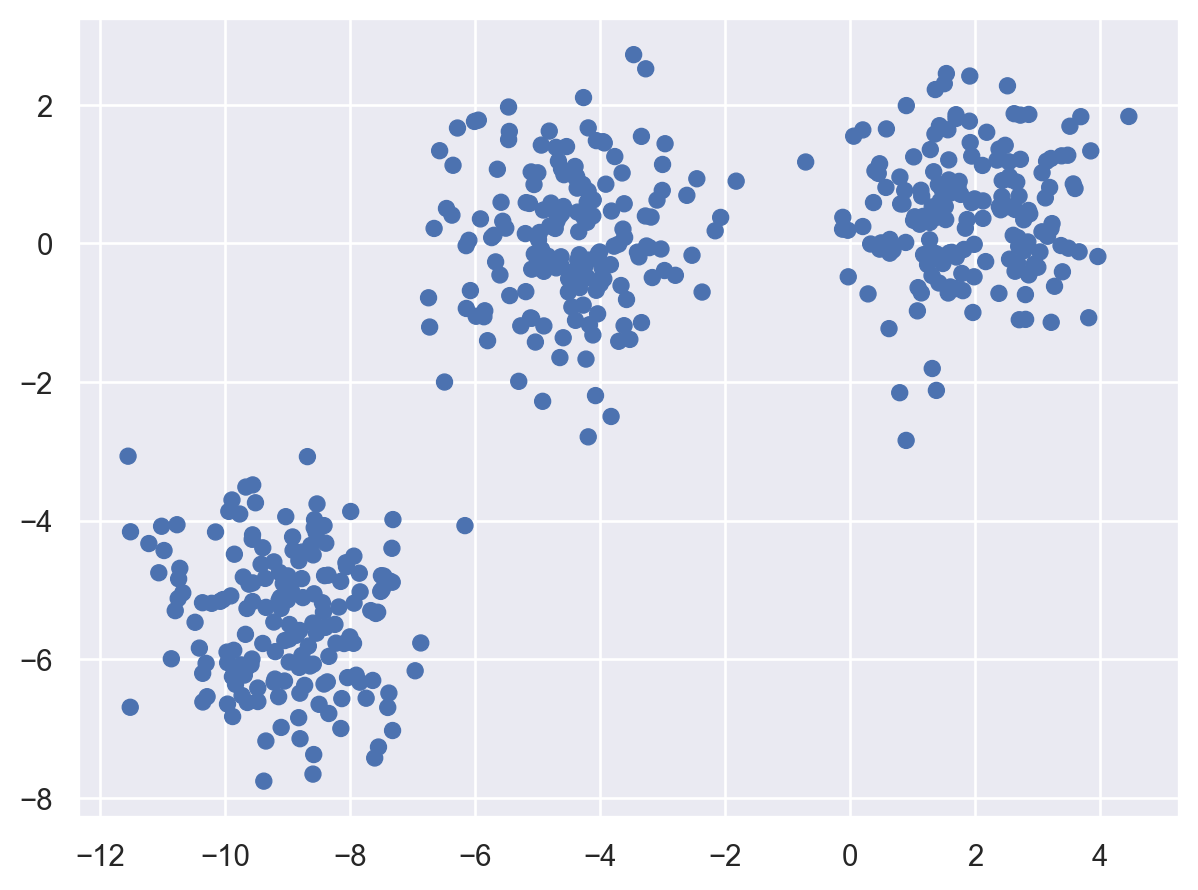

In [26]:
from sklearn.datasets import make_blobs
import numpy as np


X, y = make_blobs(n_samples=500, random_state=170)
so.Plot(x=X[:, 0], y=X[:, 1]).add(so.Dot())

Guardamos los datos de entrenamiento y los clusters descubiertos en un df (data frame) por comodidad.
Como vamos a usar _dos_ datasets, **con distintas codificaciones en canales** (`x, y, color` para los puntos de `X`, `x, y` para los centroides), lo más cómodo es inicializar el `so.Plot` vacío, y especificar la `data` en cada capa de marcas.

Recuerden que las características que son de _toda_ la capa, y no dependen de los datos (como `color, marker, stroke` para los centroides) se especifican en la llamada a la marca, `so.Dot` en este caso. Las características que varían con los datos se especifican al mismo nivel que la marca como `keyword arguments`.

De gusto, agregamos una capa con el punto a clasificar, y la marcamos con un diamande ("D") rojo. Fíjense que aunque sea un único punto, hay que pasar los valores de `x, y` como listas, tal como `so.Plot.add` las espera. Con `label`, armamos etiquetas útiles para la leyenda.

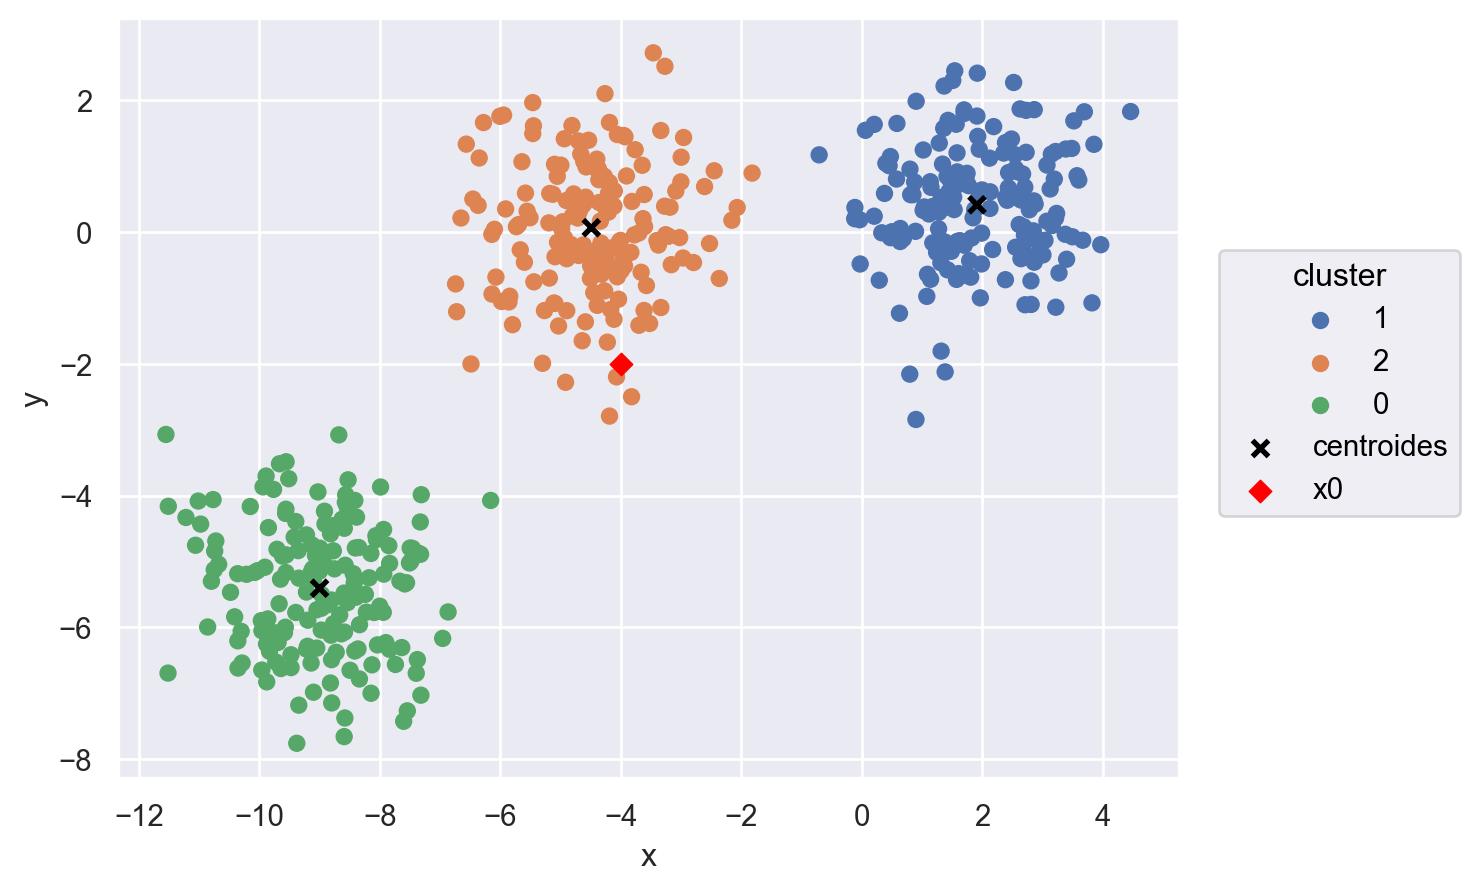

In [27]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=3).fit(X)
df = pd.DataFrame(X, columns=["x", "y"])
df["cluster"] = kmeans.predict(X).astype(str)
centroides = pd.DataFrame(kmeans.cluster_centers_, columns=["x", "y"])
(
    so.Plot()
    .add(so.Dot(), x="x", y="y", color="cluster", data=df)
    .add(
        so.Dot(color="black", marker="x", stroke=2),
        x="x",
        y="y",
        data=centroides,
        label="centroides",
    )
    .add(so.Dot(color="red", marker="D"), x=[-4], y=[-2], label="x0")
)

Para predecir, `predict` espera un primer argumento posicional "MatrixLike": un vector no es "matrixlike", por sus dimensiones, así que tanto "muchas observaciones, una feature" como "una observación, muchas features" lo confunden. El mensaje de error es informativo:

In [28]:
x0 = [-4, -2]
try:
    kmeans.predict(x0)
except ValueError as err:
    print(err)

Expected 2D array, got 1D array instead:
array=[-4. -2.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.


La manera "casera" de arreglarlo, es guardar `x0` en una lista de observaciones, con una sola observación, y pasárselo a `predict`, que devolverá una lista de predicciones (nunca un escalar) con una única predicción:

In [29]:
[x0], kmeans.predict([x0])

([[-4, -2]], array([2], dtype=int32))

Si no, podemos transformarlo en un `np.array`, y usar `reshape` como sugiere el mensaje de error:

In [30]:
x0 = np.array(x0)
print(f"Antes: {x0.shape}")
x0 = x0.reshape(1, -1)  # "Reformar" a "una (-1) fila y las necesarias (-1) columnas"
print(f"Después: {x0.shape}")

Antes: (2,)
Después: (1, 2)


In [31]:
pred = kmeans.predict(x0)[0]
centroides.loc[pred]  # para ver a qué centroide corresponde

x   -4.490306
y    0.066961
Name: 2, dtype: float64

#### El proceso de K-Fold Cross-validation con k pliegos comienza con la partición del conjunto de entrenamiento en subconjuntos cuyo tamaño es igual al k% del tamaño de los datos de entrenamiento.

Seleccione una:
- Verdadero
- ✅ Falso

Como los datos se dividen en k pliegos de igual tamaño, el tamaño de cada pliego es igual al $\frac{100}{k}\%$ de los datos de entrenamiento.

#### Se desea entrenar una red neuronal con una única neurona en la capa de output para predecir cuan recomendable es un fondo de inversion según los activos que lo conforman y su desempeño en el pasado. La variable de respuesta es numérica y se encuentra en el intervalo (-1, 1) donde -1 significa "para nada recomendable" y 1 "muy recomendable".

¿Qué función de activación resulta conveniente _si no se desea transformar la variable respuesta_?

Seleccione una:
- La función sigmoidea
- ✅ La tangente hiperbólica
- ReLU
- Ninguna es adecuada
- Cualquiera podría brindar buenos resultados, depende de la arquitectura de la red.

_Si no se desea transformar la variable respuesta_, es importante que la imagen (i.e., los valores de salida) de la función de activación de la neurona del output coincida con el dominio (i.e., los valores que puede tomar) de la respuesta, en este caso -1. Recordamos que la sigmoidea tiene imagen en el intervalo $(0, 1)$, ReLU en el $(0, \infty)$, ... ¿y la tangente hiperbólica? Yo no la recuerdo, y estamos en parcial, y sólo tengo acceso a la documentación oficial... Googleo con mi poderoso inglés, "hiperbolic tangent python", el primer resultado es de NumPy, bien: [`np.tanh`](https://numpy.org/doc/stable/reference/generated/numpy.tanh.html). Ahora, grafico y chusmeo: ¡bingo!


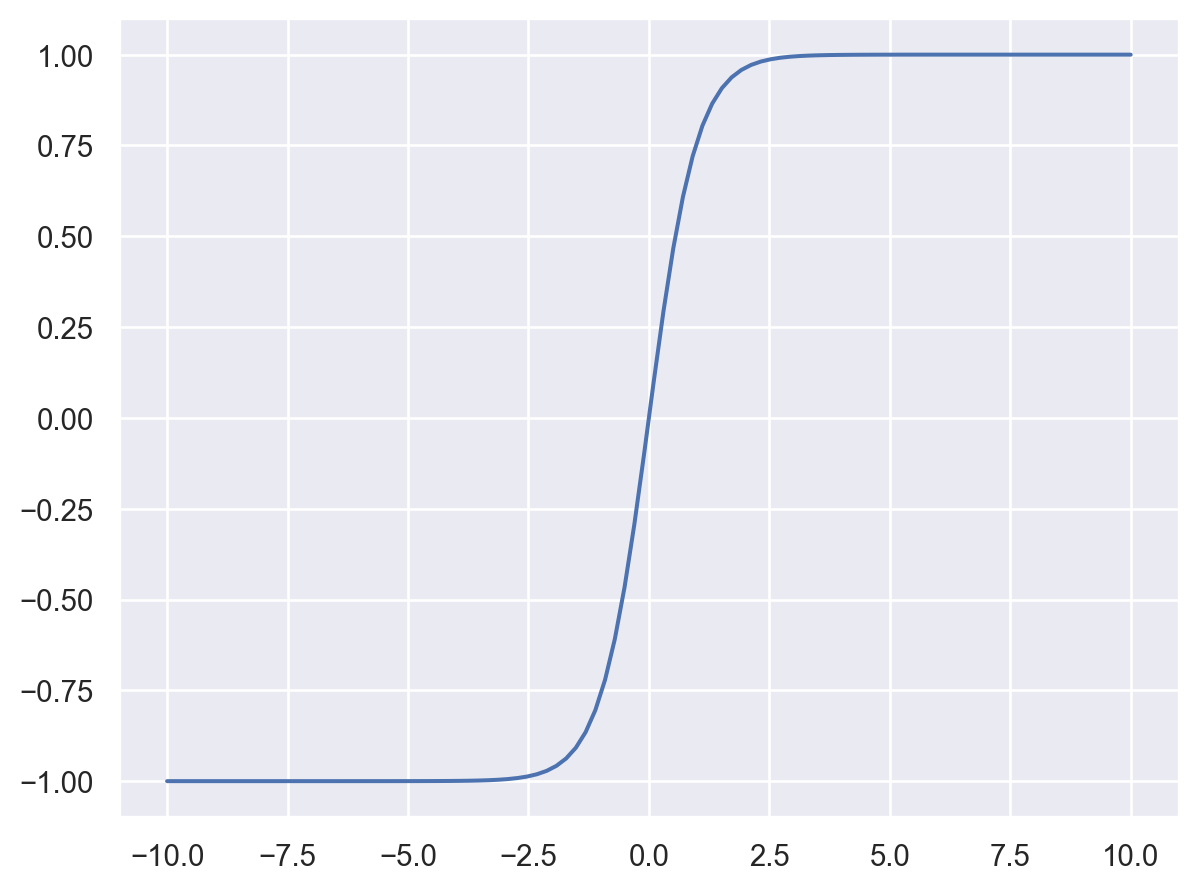

In [32]:
xs = np.linspace(-10, 10, 100)
so.Plot(x=xs, y=np.tanh(xs)).add(so.Line())

Nota: Estrictamente, la función de activación de la última capa (la de la respuesta), no tiene por qué ser igual a la de las capas "interiores", ni las de las capas interiores iguales entre sí, pero tales artes oscuras aún no les ciernen.

#### Se quiere estimar la cantidad Y de manzanas que produce un campo cuadrado de X metros de lado. Para ello se propone ajustar por regresión lineal a la variable Y como un polinomio de grado N en función de X. 

Si se toman valores de N de 1 a 10, cuál de los siguientes compartamientos puede darse con los errores de entrenamiento y testeo.

Seleccione una:
- Tanto los errores de entrenamiento como testeo aumentan al aumentar el valor de N.
- Tanto los errores de entrenamiento como testeo disminuyen al aumentar el valor de N.
- ✅ Los errores de entrenamiento disminuyen al aumentar el valor de N y los errores de testeo tienen un mínimo en N = 2.
- Los errores de entrenamiento y testeo tienen un mínimo en N = 2.

Esta es una pregunta puramente teórica: sabemos que durante el entrenamiento, agregar variables no-explicativas - slavo por problemas de precisión numérica, típicamente por variables en escalas muy dispares - no debería afectar al ECM, y hasta podría disminuirlo: después de todo, el modelo con una variable extra siembre puede asignarle 0 al coeficiente cpte. y reducirse a uno sin dicha variable.
Por su parte, durante el testeo, este mismo "sobreajuste" a la variables no-explicativas durante el entrenamiento puede perjudicar al modelo: ahora sí, es de esperar que el modelo con variables "de más" empeore su ECM.


#### Ingresar un código para generar el siguiente gráfico a partir de datos del dataset tips

El eje y representa la media de lo que pagaron los clientes.

```python
import seaborn as sns
import seaborn.objects as so

tips = sns.load_dataset('tips')
```

Sugerencia: puede ser de utilidad so.Dodge()

![](img/tips-size.png)




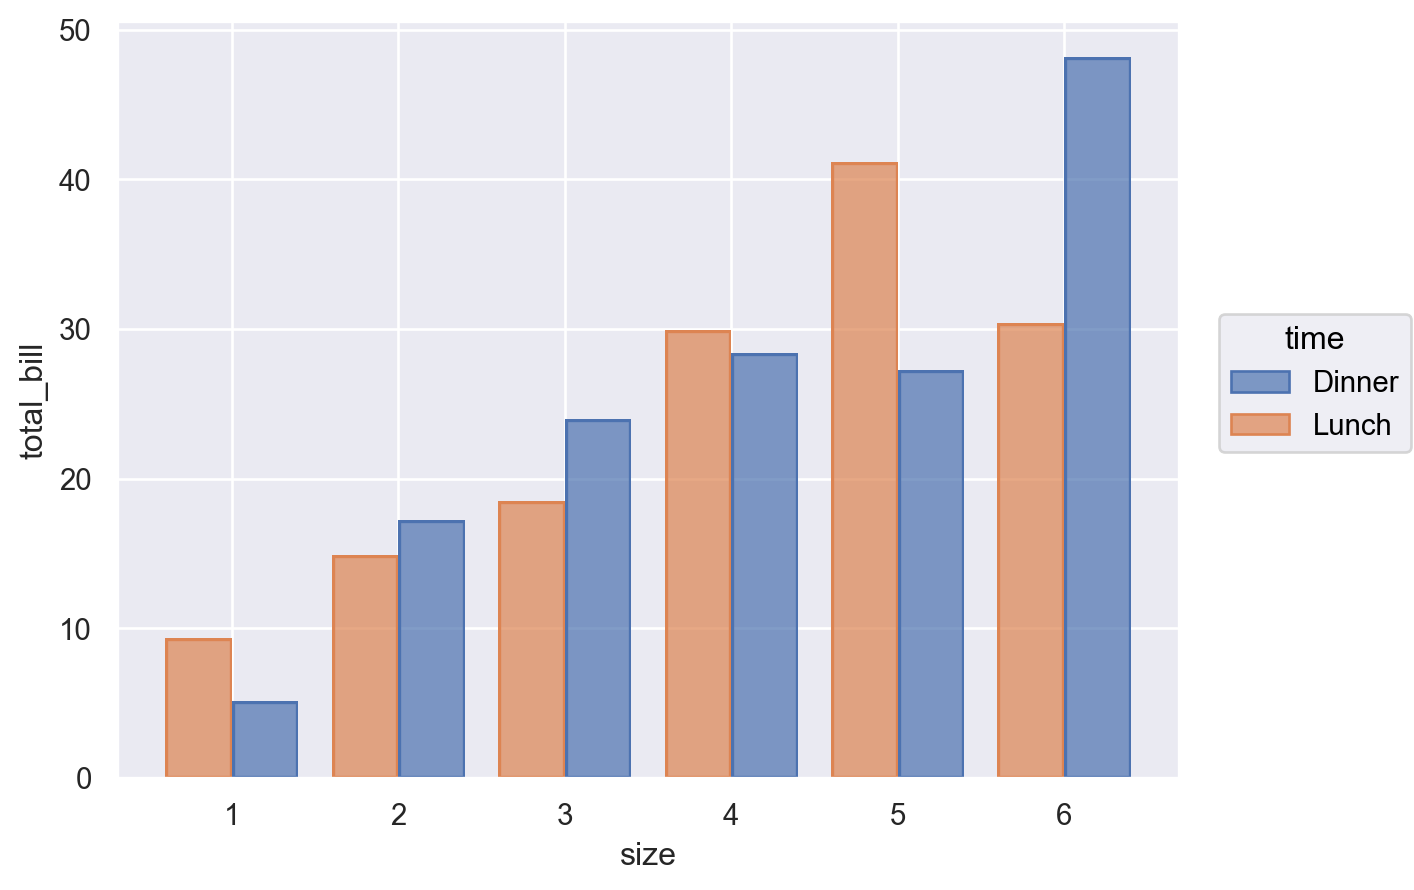

In [33]:
# Ya hemos tocado tanto `tips` que mejor importarlo de cero
so.Plot(data=sns.load_dataset("tips"), x="size", y="total_bill", color="time").add(
    so.Bar(), so.Agg("mean"), so.Dodge()
)

#### Se tienen 5 datos y se utilizó el algoritmo de K-means con K=2. Al finalizar el algoritmo los centroides de cada cluster quedaron donde se marcan las X.  

Decidir si el siguiente enunciado es verdadero o falso:

El dato marcado con una estrella pertenece al cluster azul.

![](img/kmeans.png)

Seleccione una:
- Verdadero
- ✅ Falso

A simple vista se observa que el dato estrella está a menor distancia del centroide del cluster rojo que del azul. 

#### Para el dataset tips, traduzca al español los valores de la columna day, según:

- Sun → Domingo
- Sat → Sabado
- Thur → Jueves
- Fri → Viernes

No es necesario traducir el nombre de la columna.

```python
import seaborn as sns


tips = sns.load_dataset('tips')
```

[`dict.get(key, default=None)`](https://docs.python.org/3/library/stdtypes.html#dict.get) es un método muy útil de los diccionarios: si `key` está presente en `dict`, devuelve su cpte. valor; sino, devuelve `default`. Tan común es este patrón de `apply/dict.get`, que tiene un nombre específico en pandas, [`pd.Series.map`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html):

```md
Series.map(arg, na_action=None)
    Map values of Series according to an input mapping or function.
    Used for substituting each value in a Series with another value, that may be derived from a function, a dict or a Series.
```

En cualquier caso, siempre pueden usar una comprensión de listas:

In [34]:
tips = sns.load_dataset("tips")
dias = {"Sun": "Domingo", "Sat": "Sabado", "Thur": "Jueves", "Fri": "Viernes"}
assert (tips.day.map(dias) == [dias[d] for d in tips.day]).all()
assert (tips.day.map(dias) == tips.day.apply(dias.get)).all()
tips["day"] = tips.day.map(dias)

#### Se tiene la siguiente fórmula de Wilkinson:

$$ Y \sim (X : Z) + ( W * Z )$$

donde $Y, X, W, Z$ son variables numéricas. La fórmula...

Seleccione una:
- Contempla la suma de X y W
- Contempla la interacción de X con W
- Contempla la interacción de Z con las demás variables explicativas y no tiene intercept
-  ✅ Ninguna es correcta
- Todas son correctas

1. La expansión de la fórmula queda $Y \sim X:Z + W + W:Z + Z$. Ni (a) hay una columna literal $I(X + W)$, ni (b) hay columnas independientes $X, W$ tales que uno podría reescribir el modelo como $I(X + W), W$ para "contemplar la suma de X con W".
2. La única interacción de $X$ presente es con $Z$, no $W$.
3. Aunque es cierto que "contempla la interacción de Z con las demás variables explicativas", el modelo tiene un intercept implícito por default (y no figura ni $-1$ ni $+0$ para quitarlo).
4. Luego, "Ninguna es correcta" es la opción correcta.

#### Una cierta matriz de covarianza tiene los siguientes autovalores:

$$ \lambda_1 = 5 \;\; \lambda_2= 3 \;\; \lambda_3=11 \;\; \lambda_4 =9 \;\; \lambda_5=4 $$
¿Cual es la menor cantidad de componentes principales necesaria para explicar el 60% de la varianza de los datos?

Seleccione una:
- 1
- ✅ 2
- 3
- 4
- 5

El ejericicio es idéntico al del Turno Tarde con otros números.

In [35]:
avals = np.array([5, 3, 11, 9, 4])
avals.sort()
min_var = 0.6
var_explicada = avals[::-1].cumsum() / avals.sum()
np.argmax(var_explicada > min_var) + 1

2

#### ¿En cuál(es) de estos conjuntos de datos K-Means daría los resultados que uno espera sin preprocesar los datos antes de entrenar?

![](img/kmeans2.png)

Seleccione una:
- A
- B
- Ambos
- ✅ Ninguno

K-Means minimiza la "suma de cuadrados intra-cluster", o "inercia", que no es una muy buena métricas para clsuters elongados (B) o con baricentros fuera del cluster (A). Es importante la aclaración "sin preprocesar", pues una transformación de escalado estándar (`sklearn.preprocessing.StandardScaler`, por ejemplo) le permitiría a K-Means distinguir perfectamente los clusters de (B).

#### ¿Cuál(es) de los siguientes modelos NO son modelos de Regresión Lineal?

- A. $Y = \beta_0 + \beta_1 (X\cdot Z)^2$
- B. $Y = \beta_0 + \beta_1cos(X) + \beta_2Z$
- C. $Y = \beta_0 + \beta_1e^{\beta_2X}$
- D. $Y = \beta_0 + \beta_1e^{X+Z}$
- E. $Y = \beta_0 + \beta_1X + \beta_2 Z + \beta_3 X\cdot Z$

Seleccione una:
- C) y D)
- B) y C)
- Ninguno es un modelo de Regresión Lineal
- Todos son modelos de Regresión Lineal
- ✅ C)
- A) y E)
- B), C) y E)

Todos los demás son lineales en los coeficientes $\beta_i$. $(D)$, por ejemplo, no es lineal en $X$ ni $Z$, pero sí en $e^{X+Z}$

#### El siguiente gráfico permite comparar directamente la media de las propinas que dejan los clientes por día:

![](img/boxplots.png)

Seleccione una:
- Verdadero
- ✅ Falso

La media no es un elemento visual del boxplot, así que éstos no ofrecen cómo compararlas.

#### Al entrenar una red neuronal para para predecir el precio de un inmueble según distintas características, como función de pérdida deberíamos usar:

Seleccione una:
- Binary Cross-Entropy
- Una función de activación lineal
- Ninguna es apropiada
- ✅ Error cuadrático medio

"Binary Cross-Entropy" es adecuada en problemas de clasificación binarios, una función de activación no sirve como función de pérdida (de mínima, la función de activación toma un único argumento, el potencial, y la de pérdida toma dos, la predicción y el valor real). El ECM, como ya sabemos es una pérdida muy común en problemas de regresión.